# Logistic Regression

## Overview
Logistic Regression is a **classification** algorithm (despite the name) that models the **probability** that an input belongs to a class. It applies the sigmoid function to a linear combination of features to squash the output between 0 and 1.

### Linear Regression output (unbounded):
$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

### Sigmoid / Logistic Function:
$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \in (0, 1)$$

### Decision Rule:
$$\hat{y} = \begin{cases} 1 & \text{if } \sigma(z) \geq 0.5 \\ 0 & \text{otherwise} \end{cases}$$

### Log-Loss (Binary Cross-Entropy):
$$\text{Loss} = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

---
### Topics Covered
1. Sigmoid function intuition
2. Binary classification — synthetic dataset
3. Decision boundary visualization
4. Model evaluation — Accuracy, Precision, Recall, F1, ROC-AUC
5. Confusion matrix
6. Threshold tuning
7. Multiclass classification (One-vs-Rest)
8. Regularization in Logistic Regression (C parameter)
9. Real-world offline-safe dataset
10. Feature importance via coefficients


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification, make_blobs

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Sigmoid Function — Intuition

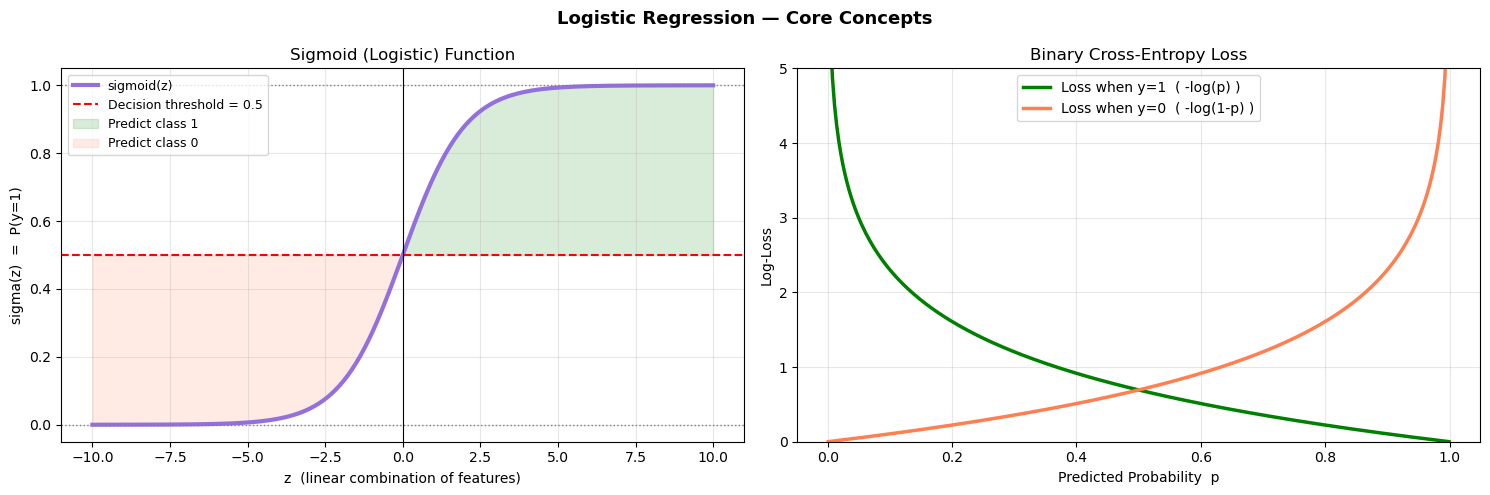

sigmoid(-10) = 4.5e-05  -> strongly class 0
sigmoid(  0) = 0.5  -> uncertain (50/50)
sigmoid( 10) = 0.999955  -> strongly class 1


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)
s = sigmoid(z)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sigmoid curve
axes[0].plot(z, s, color='mediumpurple', linewidth=3, label='sigmoid(z)')
axes[0].axhline(0.5, color='red',   linestyle='--', linewidth=1.5, label='Decision threshold = 0.5')
axes[0].axhline(1.0, color='gray',  linestyle=':',  linewidth=1)
axes[0].axhline(0.0, color='gray',  linestyle=':',  linewidth=1)
axes[0].axvline(0.0, color='black', linestyle='-',  linewidth=0.8)
axes[0].fill_between(z, 0.5, s, where=(s >= 0.5), alpha=0.15, color='green',  label='Predict class 1')
axes[0].fill_between(z, s, 0.5, where=(s <  0.5), alpha=0.15, color='coral',  label='Predict class 0')
axes[0].set_xlabel('z  (linear combination of features)')
axes[0].set_ylabel('sigma(z)  =  P(y=1)')
axes[0].set_title('Sigmoid (Logistic) Function')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.05)

# Log-loss vs predicted probability
p = np.linspace(0.001, 0.999, 300)
loss_y1 = -np.log(p)        # true label = 1
loss_y0 = -np.log(1 - p)   # true label = 0

axes[1].plot(p, loss_y1, color='green', linewidth=2.5, label='Loss when y=1  ( -log(p) )')
axes[1].plot(p, loss_y0, color='coral', linewidth=2.5, label='Loss when y=0  ( -log(1-p) )')
axes[1].set_xlabel('Predicted Probability  p')
axes[1].set_ylabel('Log-Loss')
axes[1].set_title('Binary Cross-Entropy Loss')
axes[1].set_ylim(0, 5)
axes[1].legend()

plt.suptitle('Logistic Regression — Core Concepts', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('sigmoid(-10) =', round(sigmoid(-10), 6), ' -> strongly class 0')
print('sigmoid(  0) =', round(sigmoid(  0), 6), ' -> uncertain (50/50)')
print('sigmoid( 10) =', round(sigmoid( 10), 6), ' -> strongly class 1')

## 3. Binary Classification — Generate Dataset

Dataset shape    : (500, 2)
Train / Test     : 400 / 100
Class balance    : [249 251]


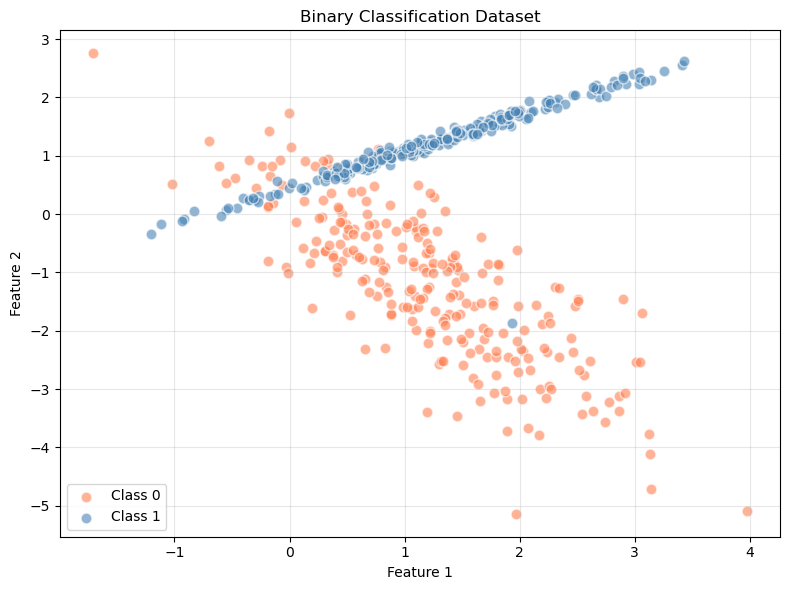

In [3]:
np.random.seed(42)

X, y = make_classification(
    n_samples=500,
    n_features=2,          # 2 features for easy visualization
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Dataset shape    : {X.shape}')
print(f'Train / Test     : {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Class balance    : {np.bincount(y)}')

# Visualize raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.6, color='coral',
            edgecolors='white', s=60, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.6, color='steelblue',
            edgecolors='white', s=60, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Fit Logistic Regression & Decision Boundary

Intercept    : -0.4656
Coefficients : [0.22421047 3.67293244]
Test Accuracy: 0.9100


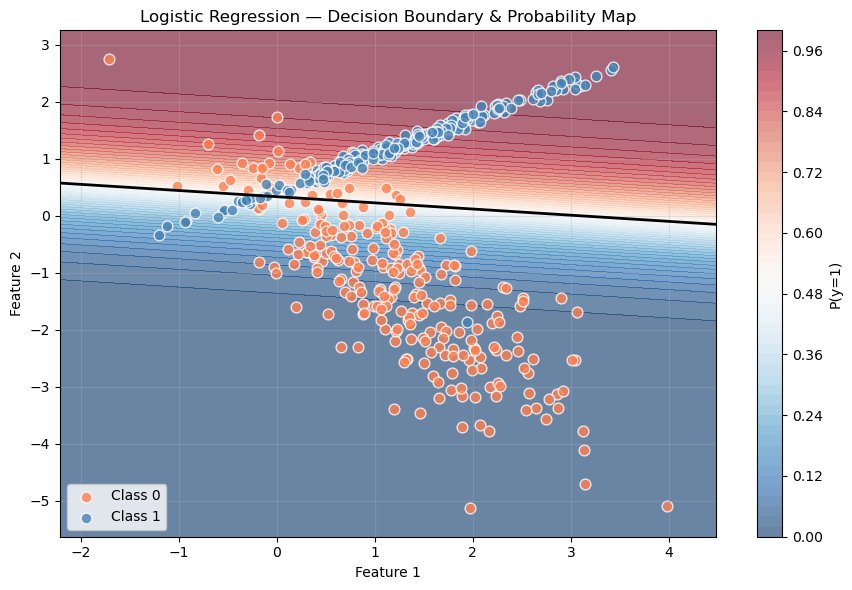

In [4]:
model = LogisticRegression(random_state=42)
model.fit(X_train_sc, y_train)

y_pred      = model.predict(X_test_sc)
y_prob      = model.predict_proba(X_test_sc)[:, 1]

print(f'Intercept    : {model.intercept_[0]:.4f}')
print(f'Coefficients : {model.coef_[0]}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# Decision boundary
def plot_decision_boundary(model, X_sc, y, scaler, title='Decision Boundary'):
    X_orig = scaler.inverse_transform(X_sc)
    x_min, x_max = X_orig[:, 0].min() - 0.5, X_orig[:, 0].max() + 0.5
    y_min, y_max = X_orig[:, 1].min() - 0.5, X_orig[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid_sc = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
    Z = model.predict_proba(grid_sc)[:, 1].reshape(xx.shape)

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
    plt.colorbar(label='P(y=1)')
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    plt.scatter(X_orig[y==0, 0], X_orig[y==0, 1],
                color='coral', edgecolors='white', s=60, alpha=0.8, label='Class 0')
    plt.scatter(X_orig[y==1, 0], X_orig[y==1, 1],
                color='steelblue', edgecolors='white', s=60, alpha=0.8, label='Class 1')
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_decision_boundary(
    model,
    np.vstack([X_train_sc, X_test_sc]),
    np.concatenate([y_train, y_test]),
    scaler,
    title='Logistic Regression — Decision Boundary & Probability Map'
)

## 5. Model Evaluation — Confusion Matrix & Classification Report

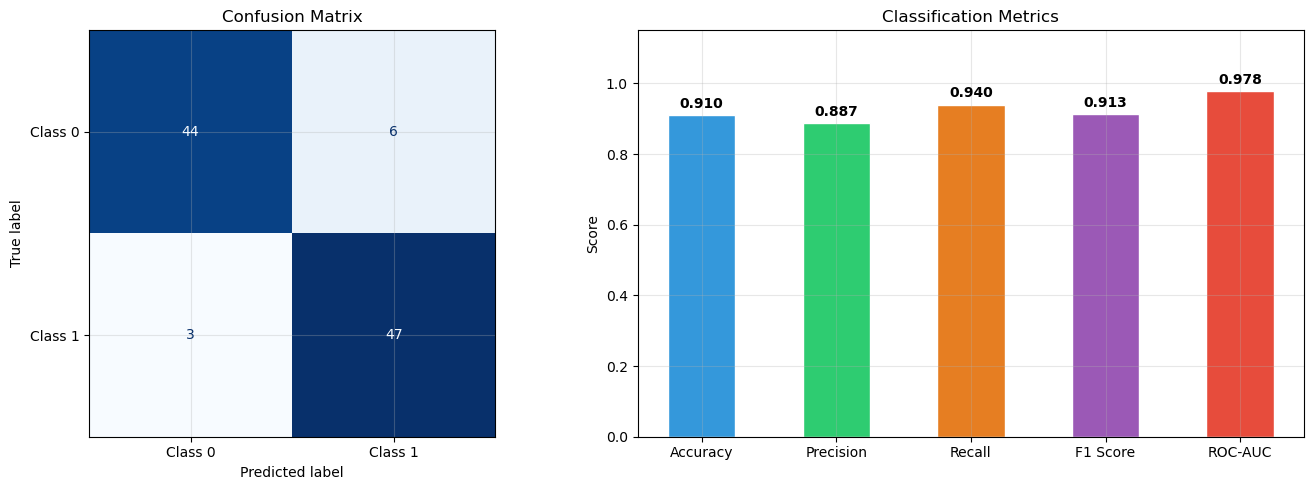


Classification Report:
              precision    recall  f1-score   support

     Class 0       0.94      0.88      0.91        50
     Class 1       0.89      0.94      0.91        50

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100

True  Negatives : 44   |   False Positives : 6
False Negatives : 3   |   True  Positives : 47


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

# Metrics bar chart
metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1 Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_prob),
}
colors_m = ['#3498db','#2ecc71','#e67e22','#9b59b6','#e74c3c']
bars = axes[1].bar(metrics.keys(), metrics.values(),
                   color=colors_m, edgecolor='white', width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score')
axes[1].set_title('Classification Metrics')
for bar, val in zip(bars, metrics.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Class 0','Class 1']))

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives : {tn}   |   False Positives : {fp}')
print(f'False Negatives : {fn}   |   True  Positives : {tp}')

## 6. ROC Curve & Precision-Recall Curve

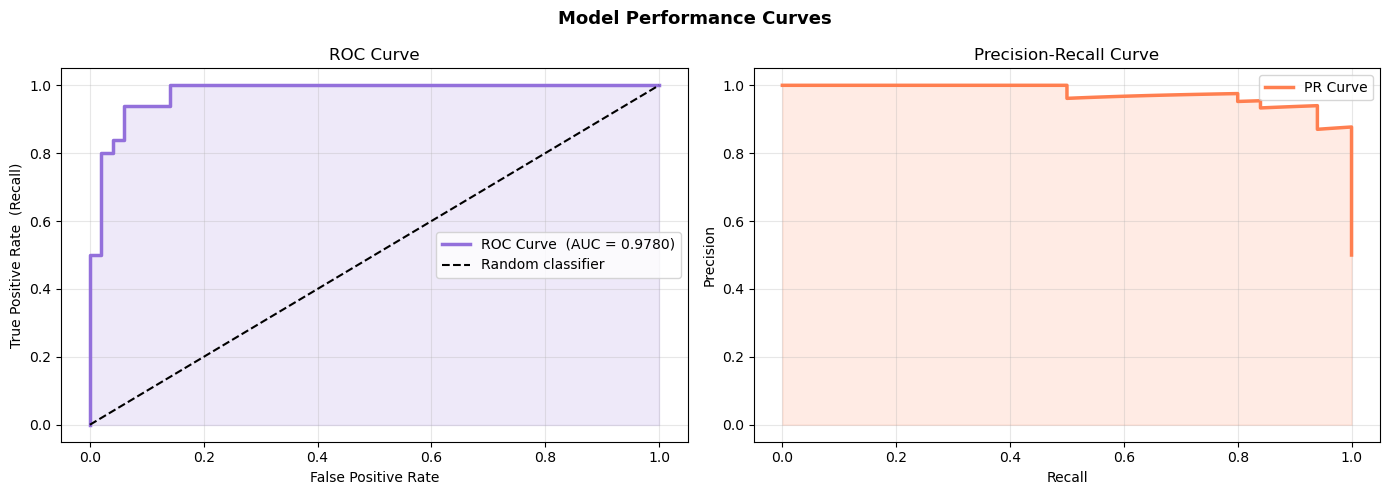

In [6]:
fpr, tpr, roc_thresh   = roc_curve(y_test, y_prob)
prec, rec, pr_thresh   = precision_recall_curve(y_test, y_prob)
auc_score              = roc_auc_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='mediumpurple', linewidth=2.5,
             label=f'ROC Curve  (AUC = {auc_score:.4f})')
axes[0].plot([0,1], [0,1], 'k--', linewidth=1.5, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='mediumpurple')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate  (Recall)')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall Curve
axes[1].plot(rec, prec, color='coral', linewidth=2.5, label='PR Curve')
axes[1].fill_between(rec, prec, alpha=0.15, color='coral')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('Model Performance Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Threshold Tuning — Precision vs Recall Tradeoff

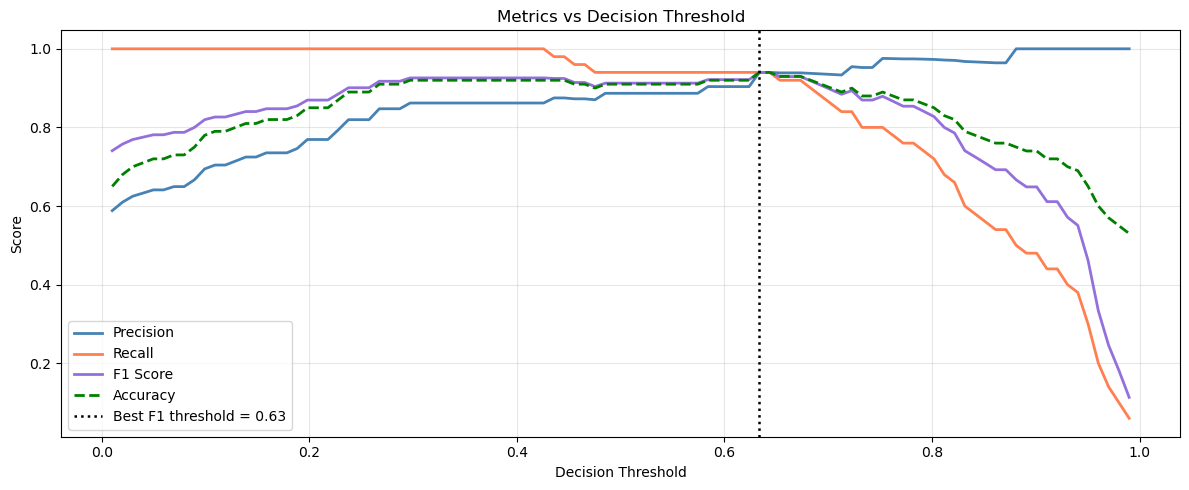

Default threshold (0.5):
  F1=0.9126  Precision=0.8868  Recall=0.9400

Best F1 threshold (0.63):
  F1=0.9400  Precision=0.9400  Recall=0.9400


In [7]:
thresholds   = np.linspace(0.01, 0.99, 100)
precisions   = []
recalls      = []
f1s          = []
accuracies   = []

for thresh in thresholds:
    y_pred_t = (y_prob >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(   recall_score(   y_test, y_pred_t, zero_division=0))
    f1s.append(       f1_score(       y_test, y_pred_t, zero_division=0))
    accuracies.append(accuracy_score( y_test, y_pred_t))

best_thresh_idx = np.argmax(f1s)
best_thresh     = thresholds[best_thresh_idx]

plt.figure(figsize=(12, 5))
plt.plot(thresholds, precisions,  color='steelblue',    linewidth=2, label='Precision')
plt.plot(thresholds, recalls,     color='coral',        linewidth=2, label='Recall')
plt.plot(thresholds, f1s,         color='mediumpurple', linewidth=2, label='F1 Score')
plt.plot(thresholds, accuracies,  color='green',        linewidth=2, linestyle='--', label='Accuracy')
plt.axvline(best_thresh, color='black', linestyle=':', linewidth=1.8,
            label=f'Best F1 threshold = {best_thresh:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Decision Threshold')
plt.legend()
plt.tight_layout()
plt.show()

y_pred_best = (y_prob >= best_thresh).astype(int)
print(f'Default threshold (0.5):')
print(f'  F1={f1_score(y_test,y_pred):.4f}  Precision={precision_score(y_test,y_pred):.4f}  Recall={recall_score(y_test,y_pred):.4f}')
print(f'\nBest F1 threshold ({best_thresh:.2f}):')
print(f'  F1={f1_score(y_test,y_pred_best):.4f}  Precision={precision_score(y_test,y_pred_best):.4f}  Recall={recall_score(y_test,y_pred_best):.4f}')

## 8. Regularization — The C Parameter

In sklearn `C = 1/alpha` — smaller C = stronger regularization (opposite of Ridge/Lasso convention).

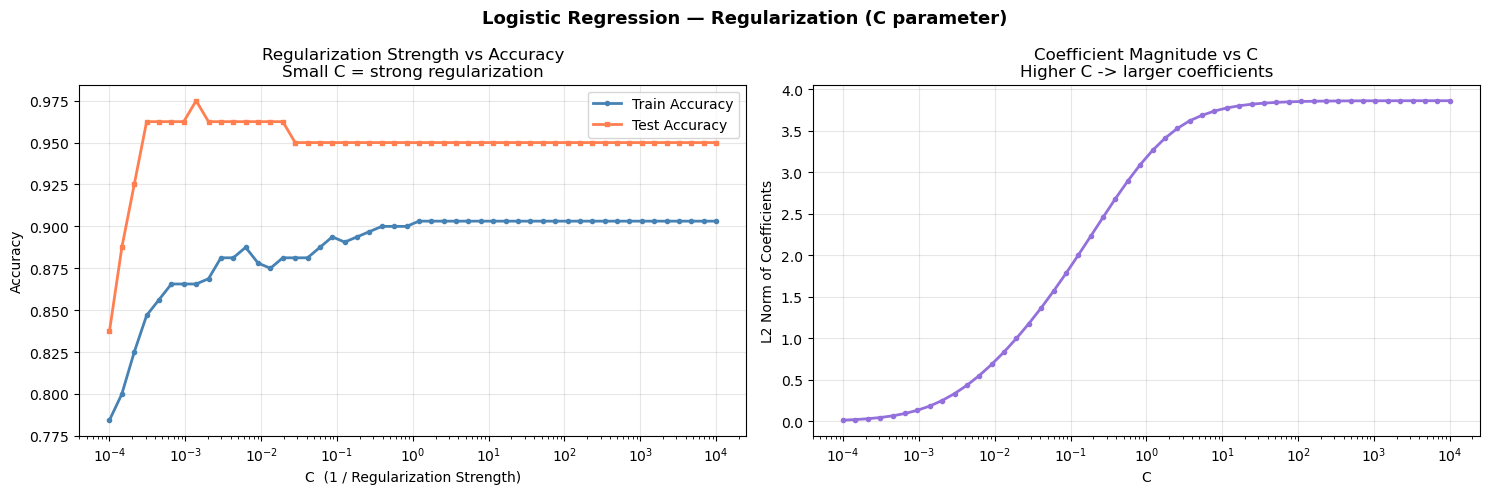

Best C by test accuracy : 0.0014
  Small C (e.g. 0.001)  ->  Strong regularization  ->  simpler model
  Large C (e.g. 1000)   ->  Weak regularization    ->  may overfit


In [8]:
# Multi-feature dataset for regularization demo
np.random.seed(0)
X_reg, y_reg = make_classification(
    n_samples=400, n_features=15, n_informative=8,
    n_redundant=4, random_state=0, return_X_y=True
)
X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=0, stratify=y_reg
)
sc_reg      = StandardScaler()
X_reg_tr_sc = sc_reg.fit_transform(X_reg_tr)
X_reg_te_sc = sc_reg.transform(X_reg_te)

C_values   = np.logspace(-4, 4, 50)
train_accs = []
test_accs  = []
coef_norms = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_reg_tr_sc, y_reg_tr)
    train_accs.append(accuracy_score(y_reg_tr, lr.predict(X_reg_tr_sc)))
    test_accs.append( accuracy_score(y_reg_te, lr.predict(X_reg_te_sc)))
    coef_norms.append(np.linalg.norm(lr.coef_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.semilogx(C_values, train_accs, 'o-', color='steelblue', linewidth=2,
             markersize=3, label='Train Accuracy')
ax1.semilogx(C_values, test_accs,  's-', color='coral',     linewidth=2,
             markersize=3, label='Test Accuracy')
ax1.set_xlabel('C  (1 / Regularization Strength)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Regularization Strength vs Accuracy\nSmall C = strong regularization')
ax1.legend()

ax2.semilogx(C_values, coef_norms, 'o-', color='mediumpurple', linewidth=2, markersize=3)
ax2.set_xlabel('C')
ax2.set_ylabel('L2 Norm of Coefficients')
ax2.set_title('Coefficient Magnitude vs C\nHigher C -> larger coefficients')

plt.suptitle('Logistic Regression — Regularization (C parameter)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_C = C_values[np.argmax(test_accs)]
print(f'Best C by test accuracy : {best_C:.4f}')
print(f'  Small C (e.g. 0.001)  ->  Strong regularization  ->  simpler model')
print(f'  Large C (e.g. 1000)   ->  Weak regularization    ->  may overfit')

## 9. Multiclass Classification (One-vs-Rest)

Multiclass Accuracy : 0.7111

              precision    recall  f1-score   support

     Class A       0.62      0.50      0.56        30
     Class B       0.56      0.63      0.59        30
     Class C       0.94      1.00      0.97        30

    accuracy                           0.71        90
   macro avg       0.71      0.71      0.71        90
weighted avg       0.71      0.71      0.71        90



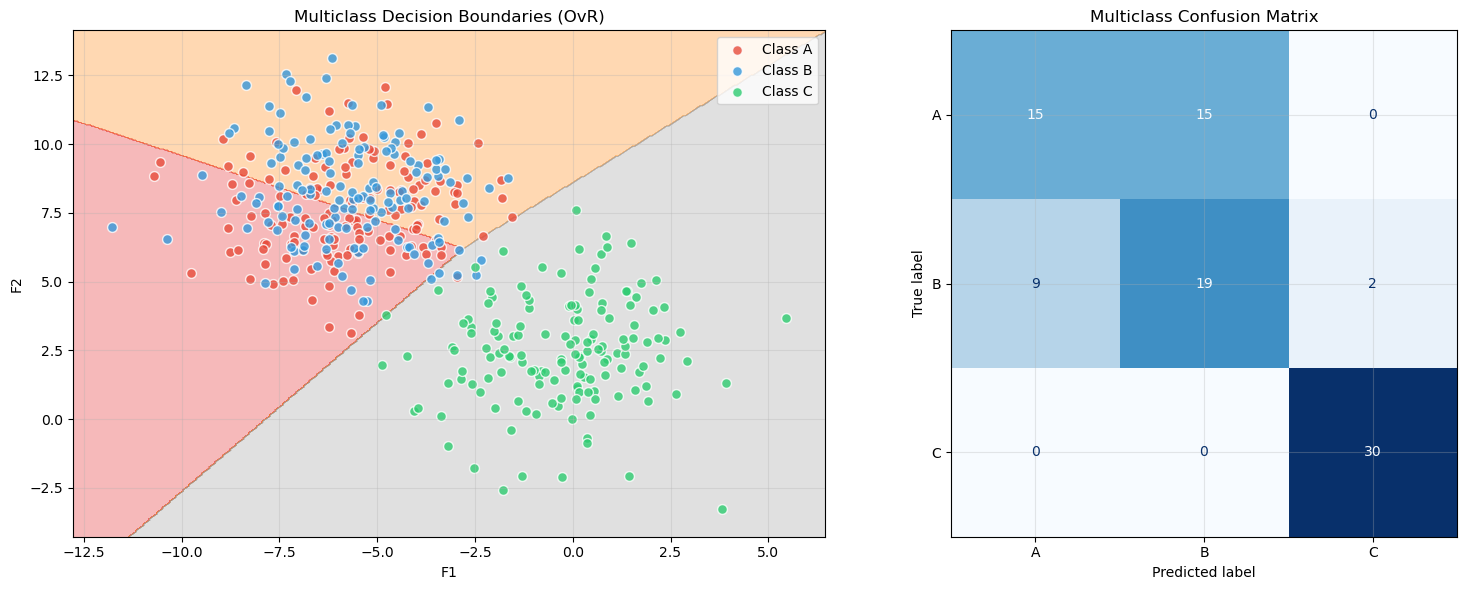

In [9]:
np.random.seed(5)
X_mc, y_mc = make_blobs(
    n_samples=450, centers=3, n_features=2,
    cluster_std=1.8, random_state=5
)

X_mc_tr, X_mc_te, y_mc_tr, y_mc_te = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)
sc_mc       = StandardScaler()
X_mc_tr_sc  = sc_mc.fit_transform(X_mc_tr)
X_mc_te_sc  = sc_mc.transform(X_mc_te)

model_mc = LogisticRegression(multi_class='ovr', max_iter=1000, random_state=42)
model_mc.fit(X_mc_tr_sc, y_mc_tr)
y_mc_pred = model_mc.predict(X_mc_te_sc)

print(f'Multiclass Accuracy : {accuracy_score(y_mc_te, y_mc_pred):.4f}')
print()
print(classification_report(y_mc_te, y_mc_pred,
      target_names=['Class A','Class B','Class C']))

# Decision boundary for 3 classes
x_min, x_max = X_mc[:, 0].min()-1, X_mc[:, 0].max()+1
y_min, y_max = X_mc[:, 1].min()-1, X_mc[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = model_mc.predict(sc_mc.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_cls = ['#e74c3c', '#3498db', '#2ecc71']
cmap_cls   = plt.cm.get_cmap('Set1', 3)

axes[0].contourf(xx, yy, Z, alpha=0.3, cmap=cmap_cls)
for cls, color, label in zip([0,1,2], colors_cls, ['Class A','Class B','Class C']):
    mask = y_mc == cls
    axes[0].scatter(X_mc[mask, 0], X_mc[mask, 1],
                    color=color, edgecolors='white', s=50, alpha=0.8, label=label)
axes[0].set_title('Multiclass Decision Boundaries (OvR)')
axes[0].legend(); axes[0].set_xlabel('F1'); axes[0].set_ylabel('F2')

# Confusion matrix
cm_mc = confusion_matrix(y_mc_te, y_mc_pred)
ConfusionMatrixDisplay(cm_mc, display_labels=['A','B','C']).plot(
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Multiclass Confusion Matrix')

plt.tight_layout()
plt.show()

## 10. Real-World Offline-Safe Dataset — Heart Disease Prediction

In [10]:
# Simulate a realistic heart disease dataset (no internet needed)
np.random.seed(99)
n_pts = 800

Age         = np.random.randint(29, 77, n_pts).astype(float)
Sex         = np.random.randint(0, 2,  n_pts).astype(float)  # 0=F 1=M
ChestPain   = np.random.randint(0, 4,  n_pts).astype(float)
RestBP      = np.random.uniform(90, 180, n_pts)
Cholesterol = np.random.uniform(150, 350, n_pts)
FastBloodSu = np.random.randint(0, 2, n_pts).astype(float)
MaxHR       = np.random.uniform(70, 200, n_pts)
ExerAngina  = np.random.randint(0, 2, n_pts).astype(float)
Oldpeak     = np.random.uniform(0, 6, n_pts)
Slope       = np.random.randint(0, 3, n_pts).astype(float)

feat_names_rw = ['Age','Sex','ChestPain','RestBP','Cholesterol',
                 'FastBloodSu','MaxHR','ExerAngina','Oldpeak','Slope']

X_rw = np.column_stack([Age, Sex, ChestPain, RestBP, Cholesterol,
                         FastBloodSu, MaxHR, ExerAngina, Oldpeak, Slope])

# Realistic target: heart disease probability
log_odds = (-3 + 0.04*Age + 0.5*Sex - 0.3*ChestPain + 0.01*RestBP
            + 0.005*Cholesterol - 0.02*MaxHR + 0.4*ExerAngina + 0.2*Oldpeak)
prob_rw  = 1 / (1 + np.exp(-log_odds))
y_rw     = (prob_rw > np.random.uniform(0, 1, n_pts)).astype(int)

print(f'Dataset shape : {X_rw.shape}')
print(f'Class balance : {np.bincount(y_rw)} (0=No disease, 1=Disease)')

X_rw_tr, X_rw_te, y_rw_tr, y_rw_te = train_test_split(
    X_rw, y_rw, test_size=0.2, random_state=42, stratify=y_rw
)

pipe_rw = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
pipe_rw.fit(X_rw_tr, y_rw_tr)

y_rw_pred = pipe_rw.predict(X_rw_te)
y_rw_prob = pipe_rw.predict_proba(X_rw_te)[:, 1]

print(f'\nTest Accuracy  : {accuracy_score(y_rw_te, y_rw_pred):.4f}')
print(f'Test ROC-AUC   : {roc_auc_score(y_rw_te,  y_rw_prob):.4f}')
print(f'Test F1 Score  : {f1_score(y_rw_te,       y_rw_pred):.4f}')

# Cross-validation
cv_scores = cross_val_score(
    pipe_rw, X_rw, y_rw,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)
print(f'\n5-Fold CV ROC-AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Per-fold scores  : {cv_scores.round(4)}')

Dataset shape : (800, 10)
Class balance : [448 352] (0=No disease, 1=Disease)

Test Accuracy  : 0.6625
Test ROC-AUC   : 0.7329
Test F1 Score  : 0.5970

5-Fold CV ROC-AUC: 0.7536 +/- 0.0352
Per-fold scores  : [0.7743 0.7297 0.7017 0.7587 0.8034]


## 11. Feature Importance via Coefficients

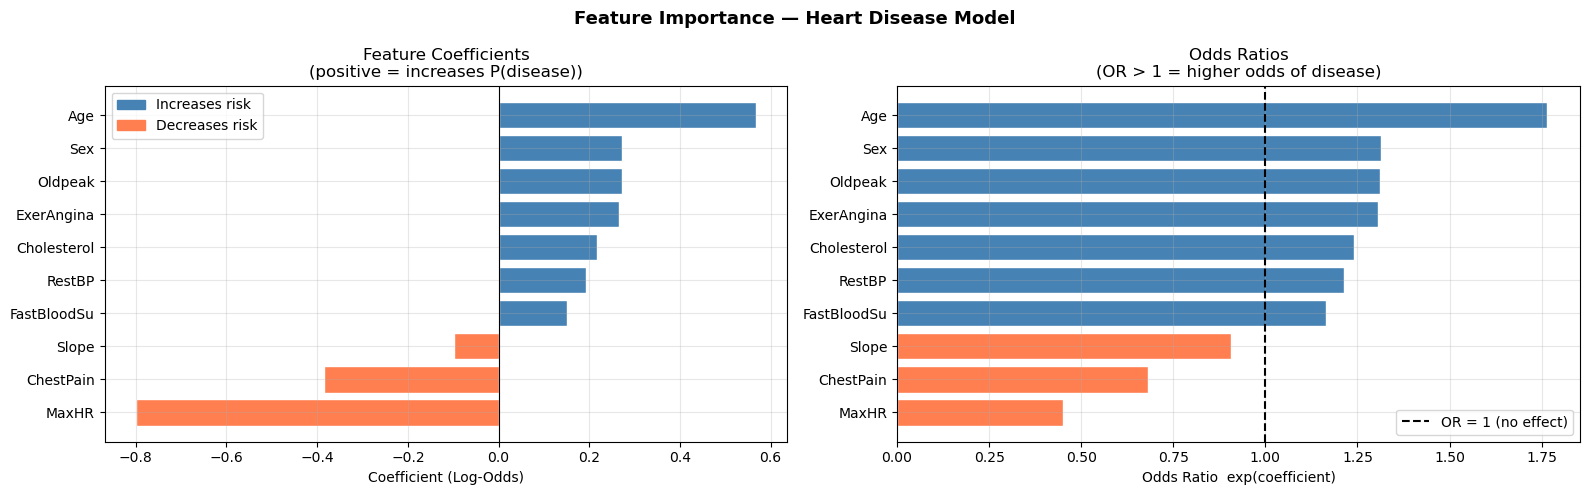


Feature Summary (sorted by |coefficient|):
    Feature  Coefficient  OddsRatio
      MaxHR      -0.8003     0.4492
        Age       0.5686     1.7659
  ChestPain      -0.3858     0.6799
        Sex       0.2722     1.3129
    Oldpeak       0.2716     1.3121
 ExerAngina       0.2658     1.3045
Cholesterol       0.2166     1.2419
     RestBP       0.1923     1.2121
FastBloodSu       0.1515     1.1636
      Slope      -0.0978     0.9068


In [11]:
coefs_rw = pipe_rw.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'Feature':     feat_names_rw,
    'Coefficient': coefs_rw,
    'OddsRatio':   np.exp(coefs_rw)
}).sort_values('Coefficient', ascending=True)

bar_colors = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-odds coefficients
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=bar_colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Coefficient (Log-Odds)')
axes[0].set_title('Feature Coefficients\n(positive = increases P(disease))')
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue', label='Increases risk'),
    mpatches.Patch(color='coral',     label='Decreases risk')
])

# Odds ratios
or_colors = ['coral' if o < 1 else 'steelblue' for o in coef_df['OddsRatio']]
axes[1].barh(coef_df['Feature'], coef_df['OddsRatio'],
             color=or_colors, edgecolor='white')
axes[1].axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (no effect)')
axes[1].set_xlabel('Odds Ratio  exp(coefficient)')
axes[1].set_title('Odds Ratios\n(OR > 1 = higher odds of disease)')
axes[1].legend()

plt.suptitle('Feature Importance — Heart Disease Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFeature Summary (sorted by |coefficient|):')
coef_df['AbsCoef'] = coef_df['Coefficient'].abs()
print(coef_df[['Feature','Coefficient','OddsRatio']]
      .sort_values('Coefficient', key=abs, ascending=False)
      .round(4).to_string(index=False))

## 12. Final Summary & Key Takeaways

In [12]:
print('=' * 68)
print('          LOGISTIC REGRESSION - KEY TAKEAWAYS')
print('=' * 68)

takeaways = [
    ('Task',            'Classification (NOT regression despite the name)'),
    ('Output',          'Probability in (0, 1) via sigmoid function'),
    ('Decision rule',   'Predict class 1 if P(y=1) >= threshold (default 0.5)'),
    ('Loss function',   'Binary cross-entropy (log-loss)'),
    ('Coefficients',    'Log-odds;  exp(coef) gives the Odds Ratio'),
    ('C parameter',     'C = 1/alpha;  small C = strong L2 regularization'),
    ('Multiclass',      'One-vs-Rest (OvR) or Softmax (multinomial)'),
    ('Scaling',         'ALWAYS standardize features before fitting'),
    ('Threshold',       'Tune threshold to balance Precision vs Recall'),
    ('Metrics',         'Use ROC-AUC and F1 for imbalanced classes'),
    ('Assumption',      'Linear decision boundary in feature space'),
    ('Limitation',      'Cannot model non-linear boundaries without feature engineering'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<18}  ->  {detail}')

print('=' * 68)

          LOGISTIC REGRESSION - KEY TAKEAWAYS
  OK  Task                ->  Classification (NOT regression despite the name)
  OK  Output              ->  Probability in (0, 1) via sigmoid function
  OK  Decision rule       ->  Predict class 1 if P(y=1) >= threshold (default 0.5)
  OK  Loss function       ->  Binary cross-entropy (log-loss)
  OK  Coefficients        ->  Log-odds;  exp(coef) gives the Odds Ratio
  OK  C parameter         ->  C = 1/alpha;  small C = strong L2 regularization
  OK  Multiclass          ->  One-vs-Rest (OvR) or Softmax (multinomial)
  OK  Scaling             ->  ALWAYS standardize features before fitting
  OK  Threshold           ->  Tune threshold to balance Precision vs Recall
  OK  Metrics             ->  Use ROC-AUC and F1 for imbalanced classes
  OK  Assumption          ->  Linear decision boundary in feature space
  OK  Limitation          ->  Cannot model non-linear boundaries without feature engineering


---
## Practice Exercises

1. **Imbalanced classes** — use `class_weight='balanced'` and compare ROC-AUC with/without it.
2. **Non-linear boundary** — add `PolynomialFeatures(degree=2)` to the pipeline and see the decision boundary change.
3. **Solver comparison** — try `solver='liblinear'`, `'saga'`, `'lbfgs'` and compare convergence speed and accuracy.
4. **GridSearchCV** — tune C and penalty (`l1`, `l2`) simultaneously.
5. **Calibration** — plot a reliability diagram (predicted probability vs actual frequency).
6. **From scratch** — implement logistic regression using gradient descent with numpy only.

---
*Notebook created for the ML Repository — Logistic Regression module.*